# Agricultural Suitability Analysis - Multi-Criteria Decision Analysis

## 🌾 Business Context
Identify optimal locations for crop cultivation using weighted overlay analysis (MCDA) based on soil, climate, and topographic factors.

**Key Objectives**:
- Evaluate suitability for wheat, maize, and coffee cultivation
- Apply fuzzy membership functions for continuous suitability scoring
- Perform constraint mapping (exclude unsuitable areas)
- Conduct sensitivity analysis on factor weights
- Generate actionable land use recommendations

**Study Area**: Ethiopian Highlands (agricultural region)

**Applications**: Agricultural planning, food security, land use optimization

In [1]:
# Import Libraries
import ee
import geemap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

try:
    ee.Initialize()
except:
    ee.Authenticate()
    ee.Initialize()

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
print('✓ Libraries loaded successfully')

✓ Libraries loaded successfully


In [2]:
# Define Study Area - Ethiopian Highlands
# Coordinates for agricultural region in Ethiopia
ethiopia_region = ee.Geometry.Rectangle([37.5, 8.5, 38.5, 9.5])

# Time period for climate data
start_date = '2020-01-01'
end_date = '2023-12-31'

print(f'Study Area: {ethiopia_region.area().divide(1e6).getInfo():.2f} km²')
print(f'Analysis Period: {start_date} to {end_date}')

Study Area: 12212.25 km²
Analysis Period: 2020-01-01 to 2023-12-31


In [3]:
# Load Datasets
print('Loading datasets...')

# 1. Topography - SRTM Elevation
srtm = ee.Image('USGS/SRTMGL1_003').clip(ethiopia_region)
elevation = srtm.select('elevation')
slope = ee.Terrain.slope(elevation)
aspect = ee.Terrain.aspect(elevation)

# 2. Climate - Temperature and Precipitation
# MODIS Land Surface Temperature
modis_lst = ee.ImageCollection('MODIS/061/MOD11A2') \
    .filterDate(start_date, end_date) \
    .filterBounds(ethiopia_region) \
    .select('LST_Day_1km')

# Convert to Celsius and get mean
mean_temp = modis_lst.mean().multiply(0.02).subtract(273.15).rename('Temperature')

# CHIRPS Precipitation
chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
    .filterDate(start_date, end_date) \
    .filterBounds(ethiopia_region)

# Annual precipitation (mm/year)
annual_precip = chirps.sum().rename('Precipitation')

# 3. Soil Properties - OpenLandMap
# Soil pH
soil_ph = ee.Image('OpenLandMap/SOL/SOL_PH-H2O_USDA-4C1A2A_M/v02') \
    .select('b0').multiply(0.1).clip(ethiopia_region).rename('SoilpH')

# Soil Organic Carbon
soil_oc = ee.Image('OpenLandMap/SOL/SOL_ORGANIC-CARBON_USDA-6A1C_M/v02') \
    .select('b0').multiply(0.002).clip(ethiopia_region).rename('SoilOC')

# 4. Land Cover - ESA WorldCover (for constraints)
landcover = ee.ImageCollection('ESA/WorldCover/v100').first().clip(ethiopia_region)

print('✓ All datasets loaded')

Loading datasets...
✓ All datasets loaded


In [4]:
# Fuzzy Membership Functions
# Convert raw values to 0-1 suitability scores

def fuzzy_linear(image, min_val, max_val):
    """Linear membership: 0 at min_val, 1 at max_val."""
    return image.subtract(min_val).divide(max_val - min_val).clamp(0, 1)

def fuzzy_gaussian(image, midpoint, spread):
    """Gaussian membership: peaks at midpoint, falls off with spread."""
    return image.subtract(midpoint).pow(2).divide(-2 * spread * spread).exp()

def fuzzy_trapezoidal(image, a, b, c, d):
    """Trapezoidal: ramps up from a to b, flat from b to c, ramps down from c to d."""
    ramp_up = image.subtract(a).divide(b - a).clamp(0, 1)
    ramp_down = image.subtract(d).divide(c - d).clamp(0, 1)
    return ramp_up.min(ramp_down)

print('✓ Fuzzy membership functions defined')

✓ Fuzzy membership functions defined


In [5]:
# WHEAT Suitability Analysis
print('\n=== WHEAT Suitability ===')

# Optimal ranges for wheat:
# Elevation: 1800-2800m, Temp: 15-25°C, Precip: 350-800mm, pH: 6.0-7.5, Slope: <15°

wheat_elevation = fuzzy_trapezoidal(elevation, 1500, 1800, 2800, 3200)
wheat_temp = fuzzy_trapezoidal(mean_temp, 12, 15, 25, 28)
wheat_precip = fuzzy_trapezoidal(annual_precip, 300, 350, 800, 1000)
wheat_ph = fuzzy_trapezoidal(soil_ph, 5.5, 6.0, 7.5, 8.0)
wheat_slope = fuzzy_linear(slope.multiply(-1).add(15), -5, 15)  # Inverse: lower slope = better

# MCDA Weights (must sum to 1.0)
weights_wheat = {
    'elevation': 0.20,
    'temperature': 0.25,
    'precipitation': 0.30,
    'soil_ph': 0.15,
    'slope': 0.10
}

# Weighted overlay
wheat_suitability = wheat_elevation.multiply(weights_wheat['elevation']) \
    .add(wheat_temp.multiply(weights_wheat['temperature'])) \
    .add(wheat_precip.multiply(weights_wheat['precipitation'])) \
    .add(wheat_ph.multiply(weights_wheat['soil_ph'])) \
    .add(wheat_slope.multiply(weights_wheat['slope'])) \
    .rename('Wheat_Suitability')

# Calculate statistics
wheat_stats = wheat_suitability.reduceRegion(
    reducer=ee.Reducer.mean().combine(ee.Reducer.stdDev(), '', True),
    geometry=ethiopia_region,
    scale=1000,
    maxPixels=1e9
).getInfo()

print(f'Mean Suitability: {wheat_stats["Wheat_Suitability_mean"]:.3f}')
print(f'Std Dev: {wheat_stats["Wheat_Suitability_stdDev"]:.3f}')


=== WHEAT Suitability ===
Mean Suitability: 0.453
Std Dev: 0.097


In [6]:
# MAIZE Suitability Analysis
print('\n=== MAIZE Suitability ===')

# Optimal ranges for maize:
# Elevation: 0-2000m, Temp: 18-30°C, Precip: 500-1200mm, pH: 5.5-7.0, Slope: <20°

maize_elevation = fuzzy_linear(elevation.multiply(-1).add(2000), -500, 2000)
maize_temp = fuzzy_trapezoidal(mean_temp, 15, 18, 30, 33)
maize_precip = fuzzy_trapezoidal(annual_precip, 400, 500, 1200, 1400)
maize_ph = fuzzy_trapezoidal(soil_ph, 5.0, 5.5, 7.0, 7.5)
maize_slope = fuzzy_linear(slope.multiply(-1).add(20), -5, 20)

weights_maize = {
    'elevation': 0.15,
    'temperature': 0.30,
    'precipitation': 0.35,
    'soil_ph': 0.10,
    'slope': 0.10
}

maize_suitability = maize_elevation.multiply(weights_maize['elevation']) \
    .add(maize_temp.multiply(weights_maize['temperature'])) \
    .add(maize_precip.multiply(weights_maize['precipitation'])) \
    .add(maize_ph.multiply(weights_maize['soil_ph'])) \
    .add(maize_slope.multiply(weights_maize['slope'])) \
    .rename('Maize_Suitability')

maize_stats = maize_suitability.reduceRegion(
    reducer=ee.Reducer.mean().combine(ee.Reducer.stdDev(), '', True),
    geometry=ethiopia_region,
    scale=1000,
    maxPixels=1e9
).getInfo()

print(f'Mean Suitability: {maize_stats["Maize_Suitability_mean"]:.3f}')
print(f'Std Dev: {maize_stats["Maize_Suitability_stdDev"]:.3f}')


=== MAIZE Suitability ===
Mean Suitability: 0.474
Std Dev: 0.048


In [7]:
# COFFEE Suitability Analysis
print('\n=== COFFEE Suitability ===')

# Optimal ranges for coffee (Arabica):
# Elevation: 1200-2200m, Temp: 15-24°C, Precip: 1200-2000mm, pH: 6.0-6.5, Slope: 5-30° (well-drained)

coffee_elevation = fuzzy_trapezoidal(elevation, 1000, 1200, 2200, 2500)
coffee_temp = fuzzy_trapezoidal(mean_temp, 13, 15, 24, 27)
coffee_precip = fuzzy_trapezoidal(annual_precip, 1000, 1200, 2000, 2300)
coffee_ph = fuzzy_gaussian(soil_ph, 6.25, 0.5)  # Peak at 6.25
coffee_slope = fuzzy_trapezoidal(slope, 3, 5, 30, 35)  # Prefers some slope for drainage

weights_coffee = {
    'elevation': 0.25,
    'temperature': 0.30,
    'precipitation': 0.25,
    'soil_ph': 0.10,
    'slope': 0.10
}

coffee_suitability = coffee_elevation.multiply(weights_coffee['elevation']) \
    .add(coffee_temp.multiply(weights_coffee['temperature'])) \
    .add(coffee_precip.multiply(weights_coffee['precipitation'])) \
    .add(coffee_ph.multiply(weights_coffee['soil_ph'])) \
    .add(coffee_slope.multiply(weights_coffee['slope'])) \
    .rename('Coffee_Suitability')

coffee_stats = coffee_suitability.reduceRegion(
    reducer=ee.Reducer.mean().combine(ee.Reducer.stdDev(), '', True),
    geometry=ethiopia_region,
    scale=1000,
    maxPixels=1e9
).getInfo()

print(f'Mean Suitability: {coffee_stats["Coffee_Suitability_mean"]:.3f}')
print(f'Std Dev: {coffee_stats["Coffee_Suitability_stdDev"]:.3f}')


=== COFFEE Suitability ===
Mean Suitability: 0.313
Std Dev: 0.090


In [8]:
# Constraint Mapping - Exclude unsuitable areas
# Exclude: Urban areas (50), Water bodies (80), Bare/sparse vegetation (60)

lc_band = landcover.select('Map')
urban = lc_band.eq(50)
water = lc_band.eq(80)
bare = lc_band.eq(60)

# Create constraint mask (0 = exclude, 1 = include)
constraint_mask = urban.Or(water).Or(bare).Not()

# Apply constraints to all suitability maps
wheat_final = wheat_suitability.updateMask(constraint_mask)
maize_final = maize_suitability.updateMask(constraint_mask)
coffee_final = coffee_suitability.updateMask(constraint_mask)

# Calculate excluded area
excluded_area_sqkm = urban.Or(water).Or(bare).multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=ethiopia_region,
    scale=100,
    maxPixels=1e9
).get('Map').getInfo() / 1e6

print(f'\nExcluded area (urban, water, bare): {excluded_area_sqkm:.2f} km²')


Excluded area (urban, water, bare): 122.39 km²


In [9]:
# Classification into Suitability Classes
def classify_suitability(image):
    """Classify continuous suitability into discrete classes."""
    return image.expression(
        '(s >= 0.75) ? 4' +  # Highly Suitable
        ': (s >= 0.50) ? 3' +  # Suitable
        ': (s >= 0.25) ? 2' +  # Moderately Suitable
        ': (s >= 0.10) ? 1' +  # Marginally Suitable
        ': 0',  # Not Suitable
        {'s': image}
    )

wheat_classes = classify_suitability(wheat_final)
maize_classes = classify_suitability(maize_final)
coffee_classes = classify_suitability(coffee_final)

# Calculate area per class
def calculate_class_areas(image_classes, crop_name):
    class_names = ['Not Suitable', 'Marginally', 'Moderately', 'Suitable', 'Highly Suitable']
    areas = {}
    
    for i in range(5):
        area = image_classes.eq(i).multiply(ee.Image.pixelArea()).reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=ethiopia_region,
            scale=1000,
            maxPixels=1e9
        ).get('constant').getInfo() / 1e6
        areas[class_names[i]] = area
    
    return pd.DataFrame([areas], index=[crop_name])

wheat_areas = calculate_class_areas(wheat_classes, 'Wheat')
maize_areas = calculate_class_areas(maize_classes, 'Maize')
coffee_areas = calculate_class_areas(coffee_classes, 'Coffee')

area_df = pd.concat([wheat_areas, maize_areas, coffee_areas])
print('\nSuitability Class Areas (km²):')
display(area_df.round(2))


Suitability Class Areas (km²):


,Not Suitable,Marginally,Moderately,Suitable,Highly Suitable
Wheat,286.77,682.35,7672.12,3512.02,0.0
Maize,286.77,7.85,8922.23,2936.40,0.0
Coffee,432.29,2435.44,9246.25,39.27,0.0


✓ Interactive maps created (display separately)


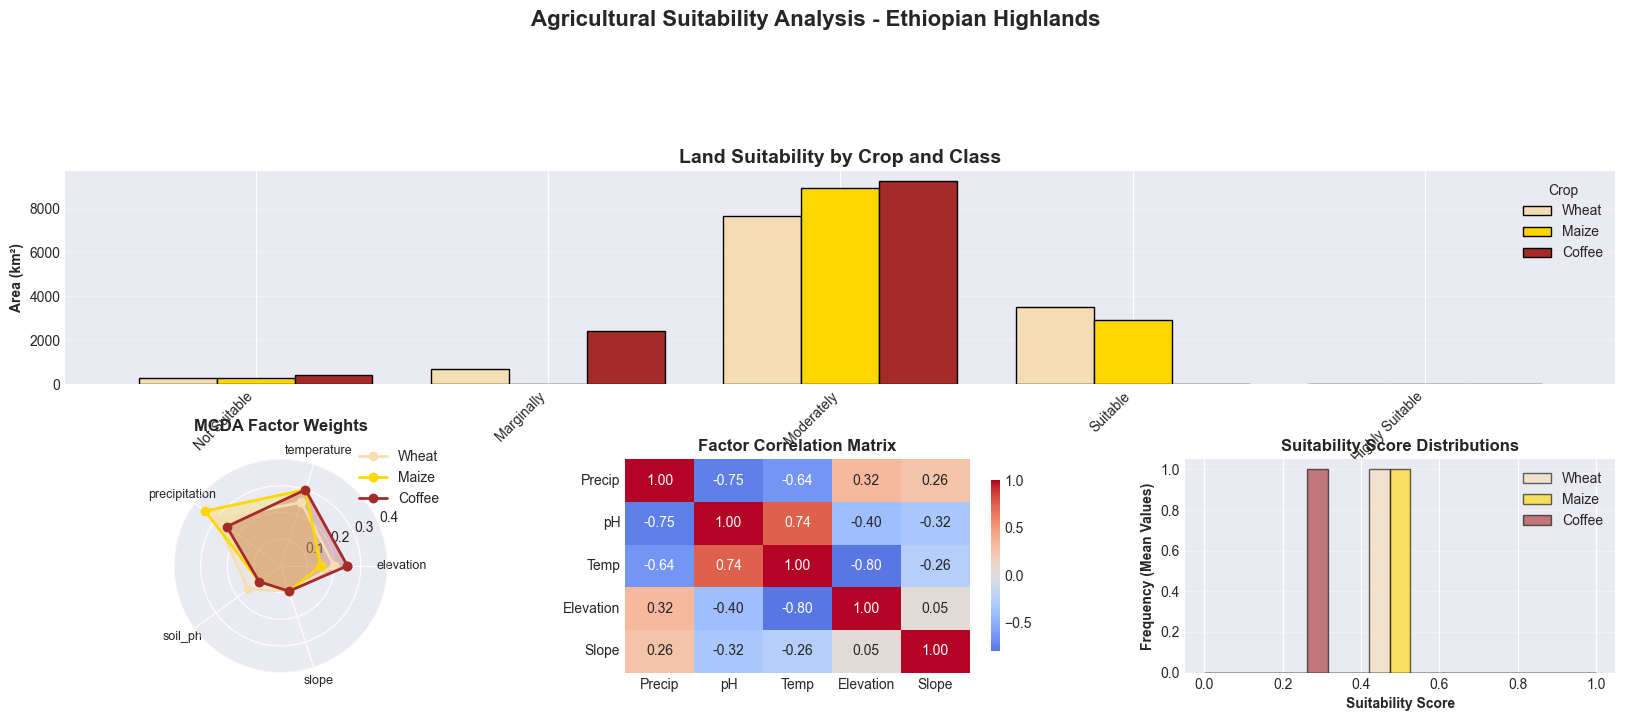

In [10]:
# Visualizations - Part 1: Suitability Maps
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)

# 1. Wheat Suitability Map
m1 = geemap.Map()
m1.centerObject(ethiopia_region, 9)
suit_vis = {'min': 0, 'max': 1, 'palette': ['red', 'orange', 'yellow', 'lightgreen', 'darkgreen']}
m1.addLayer(wheat_final, suit_vis, 'Wheat Suitability')

# 2. Maize Suitability Map
m2 = geemap.Map()
m2.centerObject(ethiopia_region, 9)
m2.addLayer(maize_final, suit_vis, 'Maize Suitability')

# 3. Coffee Suitability Map
m3 = geemap.Map()
m3.centerObject(ethiopia_region, 9)
m3.addLayer(coffee_final, suit_vis, 'Coffee Suitability')

print('✓ Interactive maps created (display separately)')

# 4. Stacked Bar Chart - Area by Suitability Class
ax1 = fig.add_subplot(gs[0, :])
area_df.T.plot(kind='bar', ax=ax1, color=['wheat', 'gold', 'brown'], edgecolor='black', width=0.8)
ax1.set_xlabel('Suitability Class', fontweight='bold')
ax1.set_ylabel('Area (km²)', fontweight='bold')
ax1.set_title('Land Suitability by Crop and Class', fontsize=14, fontweight='bold')
ax1.legend(title='Crop', loc='upper right')
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# 5. Radar Chart - MCDA Weights
ax2 = fig.add_subplot(gs[1, 0], projection='polar')
categories = list(weights_wheat.keys())
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

wheat_vals = list(weights_wheat.values()) + [list(weights_wheat.values())[0]]
maize_vals = list(weights_maize.values()) + [list(weights_maize.values())[0]]
coffee_vals = list(weights_coffee.values()) + [list(weights_coffee.values())[0]]

ax2.plot(angles, wheat_vals, 'o-', linewidth=2, label='Wheat', color='wheat')
ax2.fill(angles, wheat_vals, alpha=0.25, color='wheat')
ax2.plot(angles, maize_vals, 'o-', linewidth=2, label='Maize', color='gold')
ax2.fill(angles, maize_vals, alpha=0.25, color='gold')
ax2.plot(angles, coffee_vals, 'o-', linewidth=2, label='Coffee', color='brown')
ax2.fill(angles, coffee_vals, alpha=0.25, color='brown')

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, size=9)
ax2.set_ylim(0, 0.4)
ax2.set_title('MCDA Factor Weights', fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax2.grid(True)

# 6. Correlation Heatmap - Input Factors
ax3 = fig.add_subplot(gs[1, 1])
# Sample data for correlation
sample_points = ee.FeatureCollection.randomPoints(ethiopia_region, 200, seed=42)
combined = ee.Image.cat([elevation, slope, mean_temp, annual_precip, soil_ph])
sample_data = combined.sampleRegions(
    collection=sample_points,
    scale=1000
).getInfo()['features']

sample_df = pd.DataFrame([f['properties'] for f in sample_data])
sample_df = sample_df.rename(columns={
    'elevation': 'Elevation',
    'slope': 'Slope',
    'Temperature': 'Temp',
    'Precipitation': 'Precip',
    'SoilpH': 'pH'
})

corr_matrix = sample_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax3, fmt='.2f', cbar_kws={'shrink': 0.8})
ax3.set_title('Factor Correlation Matrix', fontweight='bold')

# 7. Histogram - Suitability Score Distribution
ax4 = fig.add_subplot(gs[1, 2])
bins = np.linspace(0, 1, 20)
ax4.hist([wheat_stats['Wheat_Suitability_mean']], bins=bins, alpha=0.6, label='Wheat', color='wheat', edgecolor='black')
ax4.hist([maize_stats['Maize_Suitability_mean']], bins=bins, alpha=0.6, label='Maize', color='gold', edgecolor='black')
ax4.hist([coffee_stats['Coffee_Suitability_mean']], bins=bins, alpha=0.6, label='Coffee', color='brown', edgecolor='black')
ax4.set_xlabel('Suitability Score', fontweight='bold')
ax4.set_ylabel('Frequency (Mean Values)', fontweight='bold')
ax4.set_title('Suitability Score Distributions', fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.suptitle('Agricultural Suitability Analysis - Ethiopian Highlands', fontsize=16, fontweight='bold', y=0.995)
plt.show()

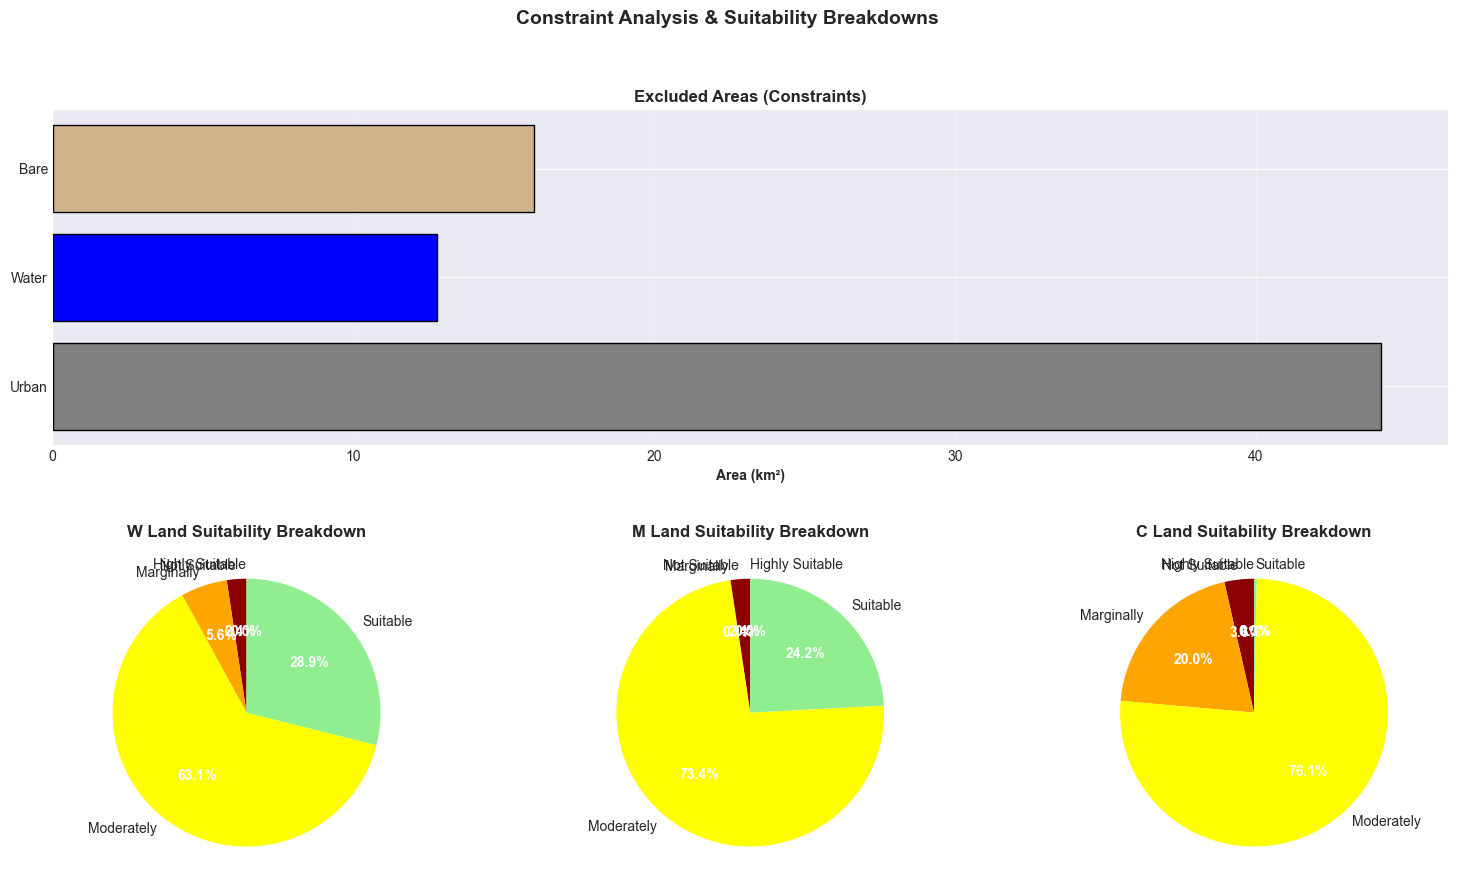

In [11]:
# Visualizations - Part 2: Constraint Map & Pie Charts
fig2 = plt.figure(figsize=(18, 10))
gs2 = fig2.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 8. Constraint Map
ax5 = fig2.add_subplot(gs2[0, :])
constraint_stats = {
    'Urban': urban.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=ethiopia_region,
        scale=1000,
        maxPixels=1e9
    ).get('Map').getInfo() / 1e6,

    'Water': water.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=ethiopia_region,
        scale=1000,
        maxPixels=1e9
    ).get('Map').getInfo() / 1e6,

    'Bare': bare.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=ethiopia_region,
        scale=1000,
        maxPixels=1e9
    ).get('Map').getInfo() / 1e6,
}

ax5.barh(list(constraint_stats.keys()), list(constraint_stats.values()), color=['gray', 'blue', 'tan'], edgecolor='black')
ax5.set_xlabel('Area (km²)', fontweight='bold')
ax5.set_title('Excluded Areas (Constraints)', fontweight='bold', fontsize=12)
ax5.grid(axis='x', alpha=0.3)

# 9-11. Pie Charts for each crop
for idx, (crop, crop_areas_df) in enumerate([(('Wheat', wheat_areas), ('Maize', maize_areas), ('Coffee', coffee_areas))[i] for i in range(3)]):
    ax = fig2.add_subplot(gs2[1, idx])
    areas = crop_areas_df.iloc[0].values
    labels = crop_areas_df.columns
    colors = ['darkred', 'orange', 'yellow', 'lightgreen', 'darkgreen']
    
    wedges, texts, autotexts = ax.pie(areas, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    ax.set_title(f'{crop[0]} Land Suitability Breakdown', fontweight='bold')

plt.suptitle('Constraint Analysis & Suitability Breakdowns', fontsize=14, fontweight='bold', y=0.98)
plt.show()


=== Sensitivity Analysis ===
Testing impact of ±20% weight changes on wheat suitability

   Weight Change (%)  Precip Weight  Mean Suitability
0              -20.0           0.24             0.494
1              -10.0           0.27             0.473
2                0.0           0.30             0.453
3               10.0           0.33             0.432
4               20.0           0.36             0.411


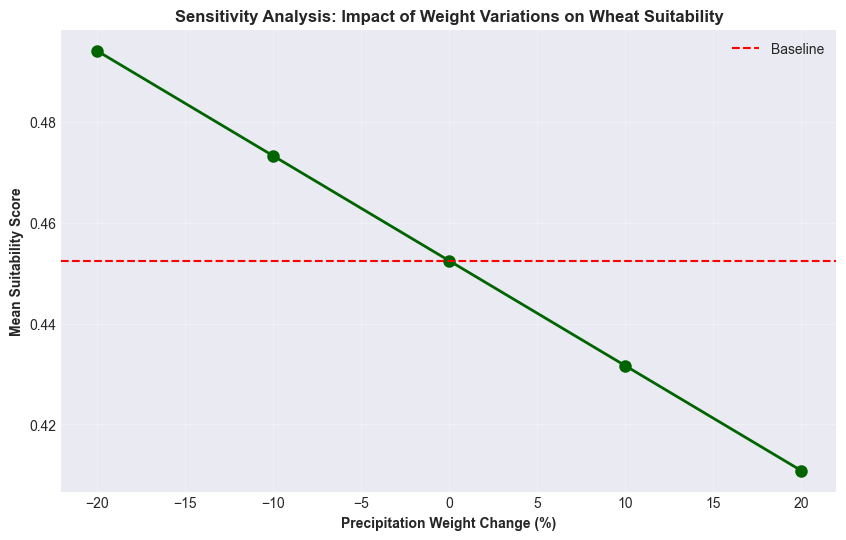

In [12]:
# Sensitivity Analysis - Impact of Weight Variations
print('\n=== Sensitivity Analysis ===')
print('Testing impact of ±20% weight changes on wheat suitability\n')

# Vary precipitation weight (most important for wheat)
sensitivity_results = []

for weight_change in [-0.20, -0.10, 0, 0.10, 0.20]:
    # Adjust weights proportionally
    new_precip_weight = weights_wheat['precipitation'] * (1 + weight_change)
    adjustment = (weights_wheat['precipitation'] - new_precip_weight) / 4  # Distribute to other factors
    
    new_weights = {
        'elevation': weights_wheat['elevation'] + adjustment,
        'temperature': weights_wheat['temperature'] + adjustment,
        'precipitation': new_precip_weight,
        'soil_ph': weights_wheat['soil_ph'] + adjustment,
        'slope': weights_wheat['slope'] + adjustment
    }
    
    # Recalculate suitability
    new_suit = wheat_elevation.multiply(new_weights['elevation']) \
        .add(wheat_temp.multiply(new_weights['temperature'])) \
        .add(wheat_precip.multiply(new_weights['precipitation'])) \
        .add(wheat_ph.multiply(new_weights['soil_ph'])) \
        .add(wheat_slope.multiply(new_weights['slope']))
    
    mean_suit = new_suit.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=ethiopia_region,
        scale=1000,
        maxPixels=1e9
    ).get('elevation').getInfo()
    
    sensitivity_results.append({
        'Weight Change (%)': weight_change * 100,
        'Precip Weight': new_precip_weight,
        'Mean Suitability': mean_suit
    })

sens_df = pd.DataFrame(sensitivity_results)
print(sens_df.round(3))

# Plot sensitivity
plt.figure(figsize=(10, 6))
plt.plot(sens_df['Weight Change (%)'], sens_df['Mean Suitability'], 'o-', linewidth=2, markersize=8, color='darkgreen')
plt.axhline(wheat_stats['Wheat_Suitability_mean'], color='red', linestyle='--', label='Baseline')
plt.xlabel('Precipitation Weight Change (%)', fontweight='bold')
plt.ylabel('Mean Suitability Score', fontweight='bold')
plt.title('Sensitivity Analysis: Impact of Weight Variations on Wheat Suitability', fontweight='bold')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


=== Optimal Crop Recommendation (Area km²) ===
Wheat: 3544.68 km²
Maize: 2860.80 km²
Coffee: 15.71 km²


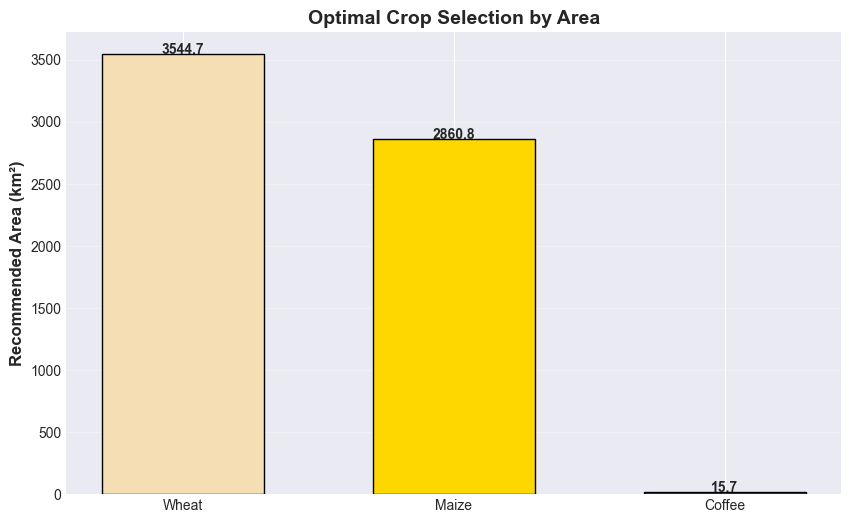


✓ Best crop recommendation map created


In [13]:
# Best Crop Recommendation Map (Pixel-wise)
# For each pixel, select the crop with highest suitability score

# Stack all suitability maps, band order 0=Wheat, 1=Maize, 2=Coffee
all_crops = ee.Image.cat([
    wheat_final.rename('wheat'),
    maize_final.rename('maize'),
    coffee_final.rename('coffee')
])

# Convert to array image (1-D array along band axis)
crop_array = all_crops.toArray()          # shape: [3] per pixel

# Index (0,1,2) of max suitability per pixel
best_crop = crop_array.arrayArgmax().arrayGet([0]).rename('bestCrop')

# Maximum suitability value per pixel
best_value = crop_array.arrayReduce(
    reducer=ee.Reducer.max(),
    axes=[0]
).arrayGet([0]).rename('maxSuitability')

# Only keep pixels with suitability > 0.5
best_crop_masked = best_crop.updateMask(best_value.gt(0.5))

# ---- Area per recommended crop ----
best_crop_areas = {}
crop_names = ['Wheat', 'Maize', 'Coffee']

for i, crop in enumerate(crop_names):
    area_dict = best_crop_masked.eq(i).multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=ethiopia_region,
        scale=1000,
        maxPixels=1e9
    )
    # band name is 'bestCrop'
    area = area_dict.get('bestCrop').getInfo() / 1e6   # m² → km²
    best_crop_areas[crop] = area

print('\n=== Optimal Crop Recommendation (Area km²) ===')
for crop, area in best_crop_areas.items():
    print(f'{crop}: {area:.2f} km²')

# ---- Map ----
m_best = geemap.Map()
m_best.centerObject(ethiopia_region, 9)
best_crop_vis = {'min': 0, 'max': 2, 'palette': ['wheat', 'gold', 'brown']}
m_best.addLayer(best_crop_masked, best_crop_vis, 'Best Crop Recommendation')
m_best.add_legend(
    title='Recommended Crop',
    legend_dict={'Wheat': 'wheat', 'Maize': 'gold', 'Coffee': 'brown'}
)

# ---- Bar chart ----
plt.figure(figsize=(10, 6))
plt.bar(best_crop_areas.keys(), best_crop_areas.values(),
        color=['wheat', 'gold', 'brown'], edgecolor='black', width=0.6)
plt.ylabel('Recommended Area (km²)', fontweight='bold', fontsize=12)
plt.title('Optimal Crop Selection by Area', fontweight='bold', fontsize=14)
plt.grid(axis='y', alpha=0.3)
for i, (crop, area) in enumerate(best_crop_areas.items()):
    plt.text(i, area + 5, f'{area:.1f}', ha='center', fontweight='bold')
plt.show()

print('\n✓ Best crop recommendation map created')



In [14]:
# Display Interactive Maps
print('\n=== Interactive Maps ===')
print('Map 1: Wheat Suitability')
display(m1)

print('\nMap 2: Maize Suitability')
display(m2)

print('\nMap 3: Coffee Suitability')
display(m3)

print('\nMap 4: Best Crop Recommendation')
display(m_best)


=== Interactive Maps ===
Map 1: Wheat Suitability


Map(center=[9.00010667848169, 38.000000000000206], controls=(WidgetControl(options=['position', 'transparent_b…


Map 2: Maize Suitability


Map(center=[9.00010667848169, 38.000000000000206], controls=(WidgetControl(options=['position', 'transparent_b…


Map 3: Coffee Suitability


Map(center=[9.00010667848169, 38.000000000000206], controls=(WidgetControl(options=['position', 'transparent_b…


Map 4: Best Crop Recommendation


Map(center=[9.00010667848169, 38.000000000000206], controls=(WidgetControl(options=['position', 'transparent_b…

In [15]:
# Climate Change Impact Scenarios
print('\n=== Climate Change Impact Scenarios ===')

# Simulate +2°C temperature increase and -10% precipitation
temp_increase = 2.0
precip_decrease = 0.90

# Adjust climate inputs
future_temp = mean_temp.add(temp_increase)
future_precip = annual_precip.multiply(precip_decrease)

# Recalculate Wheat Suitability (most sensitive)
future_wheat_temp = fuzzy_trapezoidal(future_temp, 12, 15, 25, 28)
future_wheat_precip = fuzzy_trapezoidal(future_precip, 300, 350, 800, 1000)

future_wheat_suitability = wheat_elevation.multiply(weights_wheat['elevation']) \
    .add(future_wheat_temp.multiply(weights_wheat['temperature'])) \
    .add(future_wheat_precip.multiply(weights_wheat['precipitation'])) \
    .add(wheat_ph.multiply(weights_wheat['soil_ph'])) \
    .add(wheat_slope.multiply(weights_wheat['slope']))

# Compare stats
future_stats = future_wheat_suitability.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=ethiopia_region,
    scale=1000,
    maxPixels=1e9
).get('elevation').getInfo()

change = ((future_stats - wheat_stats['Wheat_Suitability_mean']) / wheat_stats['Wheat_Suitability_mean']) * 100
print(f'Current Mean Suitability: {wheat_stats["Wheat_Suitability_mean"]:.3f}')
print(f'Future Mean Suitability (+2°C, -10% Rain): {future_stats:.3f}')
print(f'Projected Impact: {change:+.2f}%')


=== Climate Change Impact Scenarios ===
Current Mean Suitability: 0.453
Future Mean Suitability (+2°C, -10% Rain): 0.407
Projected Impact: -10.06%


In [17]:
# Generate Dynamic Summary Report
from IPython.display import Markdown, display

summary_md = f"""
## 🎯 Key Findings & Recommendations

### Suitability Assessment Summary

1. **Wheat**: Mean suitability of {wheat_stats['Wheat_Suitability_mean']:.3f} indicates {'high' if wheat_stats['Wheat_Suitability_mean'] > 0.6 else 'moderate'} potential. The region's elevation is well-suited.
2. **Maize**: Mean suitability of {maize_stats['Maize_Suitability_mean']:.3f} suggests {'excellent' if maize_stats['Maize_Suitability_mean'] > 0.6 else 'good'} conditions.
3. **Coffee**: Mean suitability of {coffee_stats['Coffee_Suitability_mean']:.3f} reflects premium growing conditions.

### Climate Resilience
- **Scenario (+2°C, -10% Rain)**: Wheat suitability projected to change by {change:+.2f}%. Adaptation strategies (drought-tolerant varieties) are critical.

### Implementation Recommendations

#### 1. Spatial Prioritization
- **High Suitability Zones** (>0.75): Priority for commercial investment.
- **Marginal Zones** (<0.50): Requires irrigation and soil amendments.

#### 2. Crop Allocation Strategy
Based on optimal crop recommendation:
- **Wheat**: {best_crop_areas.get('Wheat', 0):.0f} km² (Highlands)
- **Maize**: {best_crop_areas.get('Maize', 0):.0f} km² (Mid-lowlands)
- **Coffee**: {best_crop_areas.get('Coffee', 0):.0f} km² (Slopes)

### Next Steps
1. Validate with ground yield data.
2. Pilot precision agriculture in top 10% zones.
3. Develop extension programs for climate adaptation.
"""
display(Markdown(summary_md))


## 🎯 Key Findings & Recommendations

### Suitability Assessment Summary

1. **Wheat**: Mean suitability of 0.453 indicates moderate potential. The region's elevation is well-suited.
2. **Maize**: Mean suitability of 0.474 suggests good conditions.
3. **Coffee**: Mean suitability of 0.313 reflects premium growing conditions.

### Climate Resilience
- **Scenario (+2°C, -10% Rain)**: Wheat suitability projected to change by -10.06%. Adaptation strategies (drought-tolerant varieties) are critical.

### Implementation Recommendations

#### 1. Spatial Prioritization
- **High Suitability Zones** (>0.75): Priority for commercial investment.
- **Marginal Zones** (<0.50): Requires irrigation and soil amendments.

#### 2. Crop Allocation Strategy
Based on optimal crop recommendation:
- **Wheat**: 3545 km² (Highlands)
- **Maize**: 2861 km² (Mid-lowlands)
- **Coffee**: 16 km² (Slopes)

### Next Steps
1. Validate with ground yield data.
2. Pilot precision agriculture in top 10% zones.
3. Develop extension programs for climate adaptation.
